In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_excel("Team Stats Liverpool 25-26.xlsx")
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.fillna(df.mean(numeric_only=True))

liv = df[df["Team"] == "Liverpool"].copy()
opp = df[df["Team"] != "Liverpool"].copy()

merged = liv.merge(
    opp.drop(columns=["Team"]),
    on=["Date", "Match"],
    suffixes=("", "_opp")
)

merged = merged.drop_duplicates(subset=["Date", "Match"], keep="first")

def match_result(goals_for, goals_against):
    if goals_for > goals_against:
        return "Win"
    elif goals_for == goals_against:
        return "Draw"
    else:
        return "Lose"

merged["Result"] = merged.apply(
    lambda row: match_result(row["Goals"], row["Goals_opp"]), axis=1
)

# Select only numerical feature columns for X before scaling
numerical_features = [
    "Goals", "xG", "Shots / on target", "Passes / accurate",
    "Possession, %", "Duels / won", "Conceded goals",
    "Shots against / on target", "Defensive duels / won",
    "Aerial duels / won", "Interceptions", "Clearances",
    "Goals_opp", "xG_opp", "Shots / on target_opp", "Passes / accurate_opp",
    "Possession, %_opp", "Duels / won_opp", "Conceded goals_opp",
    "Shots against / on target_opp", "Defensive duels / won_opp",
    "Aerial duels / won_opp", "Interceptions_opp", "Clearances_opp"
]
X = merged[numerical_features]
y = merged["Result"]

encoder = LabelEncoder()
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("First 5 rows after merging:")
print(merged.head())

merged.to_csv("cleaned_features.csv", index=False)

First 5 rows after merging:
         Date                              Match             Competition  \
0  2024-07-27         Liverpool - Real Betis 1:0  World. Club Friendlies   
1  2024-07-31            Liverpool - Arsenal 2:1  World. Club Friendlies   
2  2024-08-04  Manchester United - Liverpool 0:3  World. Club Friendlies   
3  2024-08-11            Liverpool - Sevilla 4:1  World. Club Friendlies   
4  2024-08-11         Liverpool - Las Palmas 0:0  World. Club Friendlies   

   Duration       Team            Scheme  Goals    xG  Shots / on target  \
0      97.0  Liverpool  4-2-3-1 (100.0%)    1.0  0.84                8.0   
1     100.0  Liverpool    4-3-3 (100.0%)    2.0  2.05               10.0   
2      93.0  Liverpool    4-3-3 (77.64%)    3.0  2.39                9.0   
3      92.0  Liverpool    4-3-3 (100.0%)    4.0  1.30               10.0   
4      90.0  Liverpool    4-3-3 (100.0%)    0.0  1.40               13.0   

   Passes / accurate  ...  Smart passes / accurate_opp  \


In [4]:
features = merged[[
    "Goals", "xG", "Shots / on target", "Passes / accurate",
    "Possession, %", "Duels / won", "Conceded goals",
    "Shots against / on target", "Defensive duels / won",
    "Aerial duels / won", "Interceptions", "Clearances",
    "Goals_opp", "xG_opp", "Shots / on target_opp", "Passes / accurate_opp",
    "Possession, %_opp", "Duels / won_opp", "Conceded goals_opp",
    "Shots against / on target_opp", "Defensive duels / won_opp",
    "Aerial duels / won_opp", "Interceptions_opp", "Clearances_opp",
    "Result"
]]

# Save clean version
features.to_csv("cleaned_features.csv", index=False)

print("First 5 rows of the clean version:")
print(features.head())


First 5 rows of the clean version:
   Goals    xG  Shots / on target  Passes / accurate  Possession, %  \
0    1.0  0.84                8.0              668.0          63.26   
1    2.0  2.05               10.0              367.0          38.64   
2    3.0  2.39                9.0              518.0          53.86   
3    4.0  1.30               10.0              583.0          52.21   
4    0.0  1.40               13.0              667.0          62.04   

   Duels / won  Conceded goals  Shots against / on target  \
0        200.0             0.0                        7.0   
1        164.0             1.0                        9.0   
2        161.0             0.0                       14.0   
3        166.0             1.0                        7.0   
4        214.0             0.0                        6.0   

   Defensive duels / won  Aerial duels / won  ...  Passes / accurate_opp  \
0                   80.0                10.0  ...                  396.0   
1                  

In [5]:
!pip install mplsoccer # Install mplsoccer to ensure it's available


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.6 MB/s eta 0:00:00


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import os


df = pd.read_excel("/content/Team Stats Liverpool 25-26.xlsx")
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.fillna(df.mean(numeric_only=True))

def match_result(goals_for, goals_against):
    if goals_for > goals_against:
        return "Win"
    elif goals_for < goals_against:
        return "Lose"
    else:
        return "Draw"

df["Result"] = df.apply(lambda row: match_result(row["Goals"], row["Conceded goals"]), axis=1)

os.makedirs("heatmaps", exist_ok=True)
for label in ["Win", "Draw", "Lose"]:
    os.makedirs(f"heatmaps/{label}", exist_ok=True)

for i, row in df.iterrows():
    match_name = str(row["Match"]).replace("/", "-")
    result = row["Result"]

    # قيم الأربع مناطق
    zones = [
        row.get("Penalty area entries (runs / crosses)", 0),
        row.get("Touches in penalty area", 0),
        row.get("Offensive duels / won", 0),
        row.get("Recoveries / Low / Medium / High", 0)
    ]

    pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
    fig, ax = pitch.draw(figsize=(8,5))


    ax.axhline(34, color='black')
    ax.axvline(52.5, color='black')


    norm = plt.Normalize(min(zones), max(zones))
    cmap = plt.cm.Reds  # تدريج أحمر فاتح → غامق

    rects = [
        (0,0,52.5,34),    # أسفل يسار
        (52.5,0,105,34),  # أسفل يمين
        (0,34,52.5,68),   # أعلى يسار
        (52.5,34,105,68)  # أعلى يمين
    ]

    for (x1,y1,x2,y2), val in zip(rects, zones):
        color = cmap(norm(val))
        ax.add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1,
                                   facecolor=color, alpha=0.7))

    #  Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04, label="Intensity")

    plt.title(f"Heatmap (4 zones) - {match_name}")
    plt.savefig(f"heatmaps/{result}/{match_name}.png")
    plt.close()

 **DNN**


Accuracy: 0.9166666865348816
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         2
           2       0.90      1.00      0.95         9

    accuracy                           0.92        12
   macro avg       0.63      0.67      0.65        12
weighted avg       0.84      0.92      0.88        12



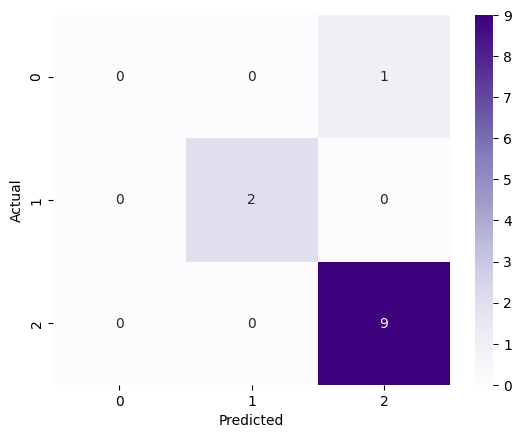

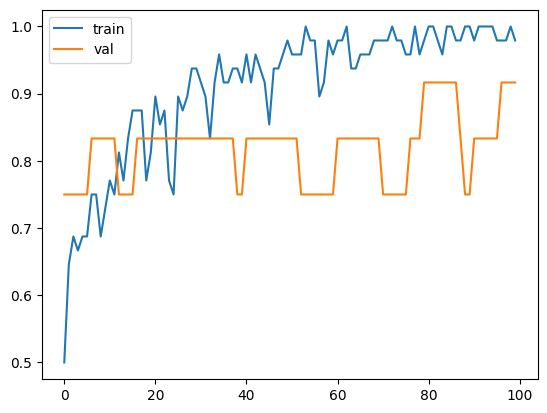

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

dnn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

dnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_dnn = dnn_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), verbose=0)

loss, acc = dnn_model.evaluate(X_test, y_test, verbose=0)
print("Accuracy:", acc)

y_pred_dnn = dnn_model.predict(X_test)
y_pred_dnn_classes = y_pred_dnn.argmax(axis=1)

print(classification_report(y_test, y_pred_dnn_classes))

cm = confusion_matrix(y_test, y_pred_dnn_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.plot(history_dnn.history['accuracy'], label='train')
plt.plot(history_dnn.history['val_accuracy'], label='val')
plt.legend()
plt.show()



**CNN**

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Prepare data for CNN
datagen_cnn = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen_cnn = datagen_cnn.flow_from_directory(
    "heatmaps/",
    target_size=(64,64),
    batch_size=16,
    class_mode="categorical",
    subset="training"
)

val_gen_cnn = datagen_cnn.flow_from_directory(
    "heatmaps/",
    target_size=(64,64),
    batch_size=16,
    class_mode="categorical",
    subset="validation"
)

# Build CNN model
cnn_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(64,64,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(train_gen_cnn.num_classes, activation="softmax")
])

# Compile & Train
cnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
history_cnn = cnn_model.fit(train_gen_cnn, validation_data=val_gen_cnn, epochs=40)


Found 88 images belonging to 3 classes.
Found 22 images belonging to 3 classes.
Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 313ms/step - accuracy: 0.4318 - loss: 1.5443 - val_accuracy: 0.4545 - val_loss: 0.9473
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - accuracy: 0.4545 - loss: 0.9513 - val_accuracy: 0.4545 - val_loss: 0.9386
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - accuracy: 0.4545 - loss: 0.9554 - val_accuracy: 0.4091 - val_loss: 0.9328
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - accuracy: 0.4886 - loss: 0.9503 - val_accuracy: 0.4545 - val_loss: 0.9288
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 234ms/step - accuracy: 0.6250 - loss: 0.9284 - val_accuracy: 0.5000 - val_loss: 0.9251
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - accuracy: 0.5795 - loss: 0.9152 - val_accuracy: 0.5455 - val_loss: 0.9204
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 363ms/step - accuracy: 0.6250 - loss: 0.9173 - val_accuracy: 0.6364 - val_loss: 0.9195
Epoch 8/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s